### code for comparing quality of automatic and manual transcriptions

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import quail
import pickle
import random
import re
import os
import json
import difflib
from num2words import num2words
from nltk.corpus import stopwords
from scipy.signal import resample
from scipy.stats import pearsonr, sem
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### set paths

In [2]:
data_dir = '../../../data/'
auto_dir = data_dir+'transcriptions/automatic/'
man_dir = data_dir+'transcriptions/manual/'

### load data

In [3]:
with open(data_dir+'pickles/id_maps.p', 'rb') as f:
    id_maps = pickle.load(f)

In [4]:
def load_transcript(path):

    try:
        with open(path, 'r') as f:
            transcript = f.read()
        # format automatic transcripts
        if '.wav' in path:
            transcript = ' '.join([line.split(',')[0].lower() for line in transcript.split('\n')])
        else:
            transcript = transcript.lower() 
        return transcript

    except FileNotFoundError:
        print(f'No transcript at {path}')
        return

In [5]:
autos = dict.fromkeys(id_maps.keys())
mans = dict.fromkeys(id_maps.keys())

for sid, maps in id_maps.items():
    tid1 = maps['session 1']
    tid2 = maps['session 2']
    
    for method_dict, root in zip([autos, mans], [auto_dir, man_dir]):
        ext = '.txt'
        if 'automatic' in root:
            ext = f'-corrected.wav{ext}'
            
        rec1_path = os.path.join(root, sid, tid1, f'{tid1}-recall{ext}')
        pred_path = os.path.join(root, sid, tid1, f'{tid1}-prediction{ext}')
        del_path = os.path.join(root, sid, tid2, f'{tid2}-delayed{ext}')
        rec2_path = os.path.join(root, sid, tid2, f'{tid2}-recall{ext}')

        zipit = zip(['rec1', 'prediction', 'delayed', 'rec2'], [rec1_path, pred_path, del_path, rec2_path])

        method_dict[sid] = {rectype : load_transcript(path) for rectype, path in zipit}

No transcript at ../../../data/transcriptions/manual/MD-101218-A-01/debugIEH2T:debugDLVLJ/debugIEH2T:debugDLVLJ-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-A-01/debugIEH2T:debugDLVLJ/debugIEH2T:debugDLVLJ-prediction.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-A-01/debug2Ea7T:debugosNZ7/debug2Ea7T:debugosNZ7-delayed.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-A-01/debug2Ea7T:debugosNZ7/debug2Ea7T:debugosNZ7-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-B-01/debugBUnNA:debugLtZcs/debugBUnNA:debugLtZcs-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-B-01/debugBUnNA:debugLtZcs/debugBUnNA:debugLtZcs-prediction.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-B-01/debugQEynG:debugpwxCU/debugQEynG:debugpwxCU-delayed.txt
No transcript at ../../../data/transcriptions/manual/MD-101218-B-01/debugQEynG:debugpwxCU/debugQEynG:debugpwxCU-recall.txt
No tra

No transcript at ../../../data/transcriptions/manual/MD-021919-A-01/debugKTkCo:debugh4yBd/debugKTkCo:debugh4yBd-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-A-01/debugKTkCo:debugh4yBd/debugKTkCo:debugh4yBd-prediction.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-A-01/debugvVhQW:debugSoY0N/debugvVhQW:debugSoY0N-delayed.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-A-01/debugvVhQW:debugSoY0N/debugvVhQW:debugSoY0N-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-B-01/debugBbcu2:debugep6I7/debugBbcu2:debugep6I7-recall.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-B-01/debugBbcu2:debugep6I7/debugBbcu2:debugep6I7-prediction.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-B-01/debugJ2iI9:debugD6tOV/debugJ2iI9:debugD6tOV-delayed.txt
No transcript at ../../../data/transcriptions/manual/MD-021919-B-01/debugJ2iI9:debugD6tOV/debugJ2iI9:debugD6tOV-recall.txt
No tra

In [6]:
# check that both datasets contain all transcripts
for sid in id_maps.keys():
    if all(autos[sid].values()) and not all(mans[sid].values()):
        missing = ', '.join([k for k in mans[sid].keys() if mans[sid][k] is None])
        print(f'{sid} : no manual transcript for {missing}')
    if all(mans[sid].values()) and not all(autos[sid].values()):
        missing = ', '.join([k for k in autos[sid].keys() if autos[sid][k] is None])
        print(f'{sid} : no automatic transcript for {missing}')

MD-101218-A-01 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-B-01 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-A-02 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-B-02 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-A-03 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-B-03 : no manual transcript for rec1, prediction, delayed, rec2
MD-101218-A-04 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-B-01 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-B-02 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-A-02 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-A-03 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-B-03 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-A-04 : no manual transcript for rec1, prediction, delayed, rec2
MD-101318-B-04 : no manual transcript 

# compare transcript content directly

### compare lengths

In [7]:
# compare transcript lengths
print('Average number of words:')
print(f'automatic : {np.mean([len(autos[sid][k].split()) for k in autos[sid].keys() for sid in autos.keys()])}')
print(f'manual : {np.mean([len(mans[sid][k].split()) for k in mans[sid].keys() for sid in mans.keys() if mans[sid][k]])}')
print('\n')
print('Average number of (non-whitespace) characters:')
print(f'automatic : {np.mean([len(autos[sid][k].replace(" ","")) for k in autos[sid].keys() for sid in autos.keys()])}')
print(f'manual : {np.mean([len(mans[sid][k].replace(" ","")) for k in mans[sid].keys() for sid in mans.keys() if mans[sid][k]])}')


Average number of words:
automatic : 1236.2931034482758
manual : 1935.25


Average number of (non-whitespace) characters:
automatic : 4998.741379310345
manual : 7737.388888888889


## hit rate and false alarm rate

In [8]:
diffs = {sid : 
         {rectype : 
          None for rectype in ['rec1', 'prediction', 'delayed', 'rec2']
         } for sid in id_maps.keys()
        }

In [9]:
for sid in diffs.keys():
    for rectype in diffs[sid].keys():
        
        # leave out participants whose manual transcriptions aren't finished for now
        if not mans[sid][rectype]:
            continue
            
        man, auto = mans[sid][rectype].split(), autos[sid][rectype].split()
        # generate deltas, trim leading fromfile and tofile tags
        diff = list(difflib.unified_diff(auto, man, lineterm='', n=0))[2:]
        # parse unified diff, get bounds of matching sequences
        seqbounds = [idx for idx, word in enumerate(diff) if word.startswith('@') and idx!= 0] \
        + [len(diff)]

        misses = []
        false_alarms = []
        fa_quality = []
        lbound = 1
        for ubound in seqbounds:
            seq = diff[lbound:ubound]
            ms = [word[1:] for word in seq if word.startswith('+')]
            fas = [word[1:] for word in seq if word.startswith('-')]
            # track misses
            misses.extend(ms)
            if fas:
                # false alarms
                false_alarms.extend(fas)
                # track "quality" of false alarms
                for fa in fas:
                    best_match = difflib.get_close_matches(fa, ms, n=1)
                    if best_match:
                        quality = difflib.SequenceMatcher(a=fa, b=best_match[0]).ratio()
                        fa_quality.append((fa, best_match[0], quality))
                    else:
                        fa_quality.append((fa, None, 0))
            
            lbound = ubound + 1
        
        diffs[sid][rectype] = {
            # prop words in auto that are not in man
            'FAR' : len(false_alarms) / len(auto),
            # prop words in auto that are also in man
            'HR' : (len(auto) - len(false_alarms)) / len(man),
            'fa_quality' : fa_quality,
            'similarity' : difflib.SequenceMatcher(None, auto, man).ratio()
            'confidence' : ################
        }


## plot ROC curve

In [34]:
hrs = []
fars = []
for rectype in diffs.values():
    for data in rectype.values():
        if data:
            hrs.append(data['HR'])
            fars.append(data['FAR'])

In [39]:
thresholds = np.arange(0, 1.1, .1)


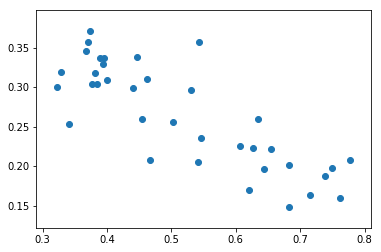

In [41]:
plt.scatter(hrs, fars)

In [78]:
gcloud_path = os.path.join(auto_dir, sid, id_maps[sid]['session 1'], 
                           id_maps[sid]['session 1']+'-recall.wav.p')

with open(gcloud_path, 'rb') as f:
    results_obj = pickle.load(f)

In [103]:
test = []
for chunk in results_obj:
    for res in chunk.results:
        # find transcript alternative with max confidence
        test.append(res.alternatives[0].confidence)
np.mean(test)

0.8833351479636298